# Aquarium motion model

An original browser-Python reinterpretation inspired by **Reference-Image Aquarium Game**, credited in the Awesome GPT-6 Astra catalog to Tim Jayas.

Sources: [original creator post](https://x.com/TimJayas/status/2095611134992945385) · [Awesome GPT-6 Astra](https://github.com/magiccreator-ai/awesome-gpt-6-astra#reference-image-aquarium-game)

> This notebook does not reproduce the creator's code, assets, prompt, or benchmark. It demonstrates a small bounded-motion model with reproducible Python.


## Look → predict → run
**Learn:** relate individual motion to an emergent group pattern.
**Predict:** if the steering toward the centroid increases, will the school become tighter?
The model uses dimensionless positions and one fixed update per step. Each line is one fish's history,
not the path of the whole school. Random numbers use a fixed seed so comparisons are repeatable.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style, animate_tracks, COLORS
style()


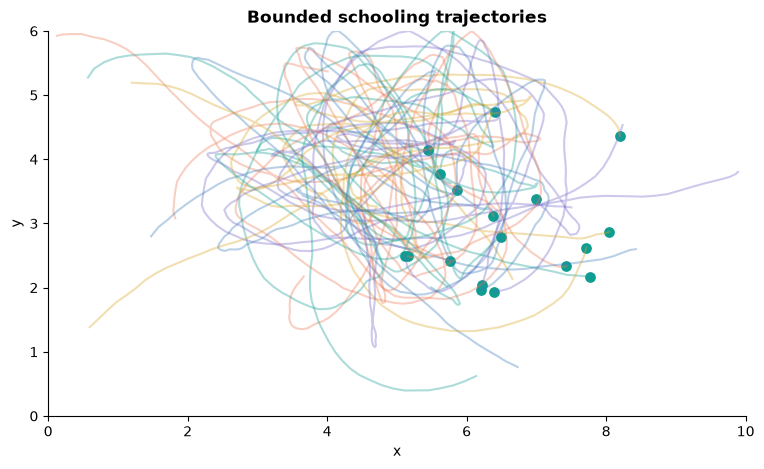

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6)
n = 18
pos = rng.uniform([0, 0], [10, 6], size=(n, 2))
vel = rng.normal(0, 0.12, size=(n, 2))
trail = []

for _ in range(180):
    # Gentle schooling: drift toward the group centroid plus random steering.
    centroid = pos.mean(axis=0)
    vel += 0.008 * (centroid - pos) + rng.normal(0, 0.015, size=vel.shape)
    speed = np.linalg.norm(vel, axis=1, keepdims=True)
    vel = vel / np.maximum(speed, 1e-9) * np.minimum(speed, 0.18)
    pos += vel
    for axis, bound in [(0, 10), (1, 6)]:
        low = pos[:, axis] < 0
        high = pos[:, axis] > bound
        vel[low | high, axis] *= -1
        pos[:, axis] = np.clip(pos[:, axis], 0, bound)
    trail.append(pos.copy())

trail = np.array(trail)
fig, ax = plt.subplots(figsize=(9, 5))
for i in range(n):
    ax.plot(trail[:, i, 0], trail[:, i, 1], alpha=.35)
ax.scatter(pos[:, 0], pos[:, 1], s=45)
ax.set(xlim=(0,10), ylim=(0,6), xlabel='x', ylabel='y', title='Bounded schooling trajectories')
plt.show()


## Try it
Change `n`, the steering coefficient, or maximum speed. A richer version could add obstacles, predator/prey rules, or depth as a third coordinate.


## Watch the same coordinates move
Scrub the player to connect the static trajectories to time. The centroid is the mean position;
spread is the root-mean-square distance from it. A compact school has low spread.


In [3]:
animate_tracks(trail,(0,10,0,6),'Bounded aquarium motion',units='step')


Interactive animation: run this cell in JupyterLite to play or scrub.

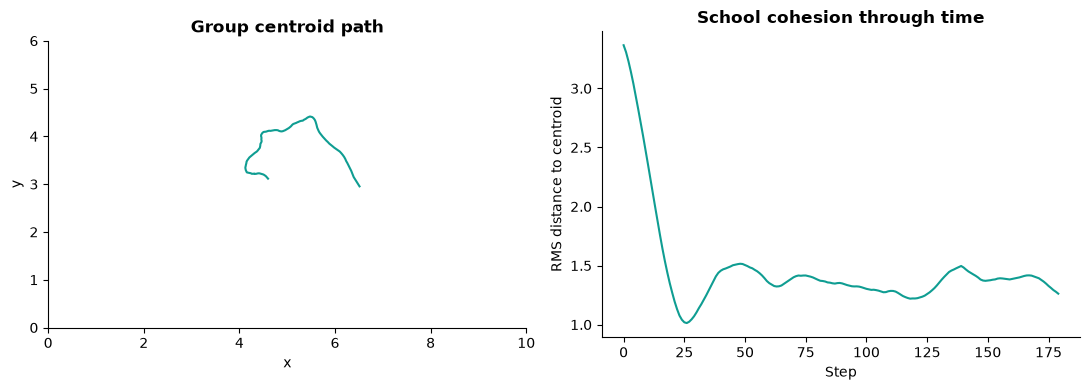

In [4]:
centers = trail.mean(axis=1)
spread = np.sqrt(np.mean(np.sum((trail-centers[:,None,:])**2,axis=2),axis=1))
fig,axes = plt.subplots(1,2,figsize=(11,4))
axes[0].plot(*centers.T,color='#0f9d92')
axes[0].set(xlim=(0,10),ylim=(0,6),title='Group centroid path',xlabel='x',ylabel='y',aspect='equal')
axes[1].plot(spread)
axes[1].set(title='School cohesion through time',xlabel='Step',ylabel='RMS distance to centroid')
fig.tight_layout(); plt.show()
assert np.all((trail >= 0) & (trail <= np.array([10,6])))


**Experiment:** change only the steering coefficient from `0.008` to `0.016`; rerun all cells.
Compare the spread curve using the same random seed. Explain whether a tighter group also means
a slower group. Extend this to ocean particles in notebook 10.
